Read rfi_and_ripple_para.md first.

author: Xu Chen, 2021.07

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import numpy.fft as fft
import sys
sys.path.append('/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/')
from util import *
from copy import deepcopy
from tqdm import tqdm

In [2]:
subname = '/data/inspur_disk04/FAST/liangtiantian/home/M31_v1/drift12/data/M31_Halo_Drift_12_arcdrift-M15_F-20200210-specs_T-bld.hdf5'
sub = h5py.File(subname,'r')
# from cli_markRFI
rfiname = './data/M31_Halo_Drift_12_arcdrift-M15_F-20200210-specs_T-bld-tr_pdr.hdf5'
rfi =  h5py.File(rfiname,'r')

# example polar xx

In [3]:
freq = sub['freq'][:]
data_x = get_data(sub,polar='xx')
#data_y = get_data(sub,polar='yy')
is_rfi = rfi['is_rfi'][:]

In [4]:
mw_use = (freq > 1420.2)&(freq < 1420.55)
rep_args = {}
rep_args['sg_window'] = 1
rep_args['sg_polyorder'] = 7
rep_args['times_lower'] = 1e4
rep_args['times_lower_thr'] = 2
rep_args['rms_sigma'] = 6

In [5]:
from baseline_2 import *

# Replace RFI or strong sources

* --rfi_method: 防止大rfi/强源干扰fft，提供三种方法：'lower','set zeros','subtract'
* --times_lower_thr: 大于RMS这么多倍的会被降低
* --times_lower: 把高流量压低，比如原来的1/1e4
* --rms_sigma: 如果区间有干扰，还是用该频率减去一个高斯平滑，得到准确的rms。此为高斯滤波的sigma。

1.'lower'降低高流量。不需要rfi文件。
    
2.'set zeros'高流量全部置零。不需要rfi文件。
    
3.'subtract'用原始值减去滤波值。
    
    * -rfi, --rfi_fname: 指定标记rfi的文件。无则自动到输入文件的上一级名为/rfi/的文件夹里找含-tr的文件，找不到则在当前路径找。
    * --mw_frange: 银河系存在的区域
    * --sg_window --sg_polyorder: savgol_filter的窗口大小(MHz)和阶数

In [6]:
data_xxs = replace_rfi(data_x,freq,is_rfi, method='subtract',mw_use = mw_use, **rep_args)

INFO: Replace RFI with subtract method ... [baseline_2]


100%|██████████| 7153/7153 [00:36<00:00, 195.46it/s]


In [7]:
rep_args = {}
rep_args['times_lower'] = 1e4
rep_args['times_lower_thr'] = 2
rep_args['rms_sigma'] = 6

In [8]:
data_xxl = replace_rfi(data_x,freq,is_rfi, method='lower',mw_use = None, **rep_args)
data_xxz = replace_rfi(data_x,freq,is_rfi, method='set zeros',mw_use = None, **rep_args)

INFO: Replace RFI with lower method ... [baseline_2]
INFO: Replace RFI with set zeros method ... [baseline_2]


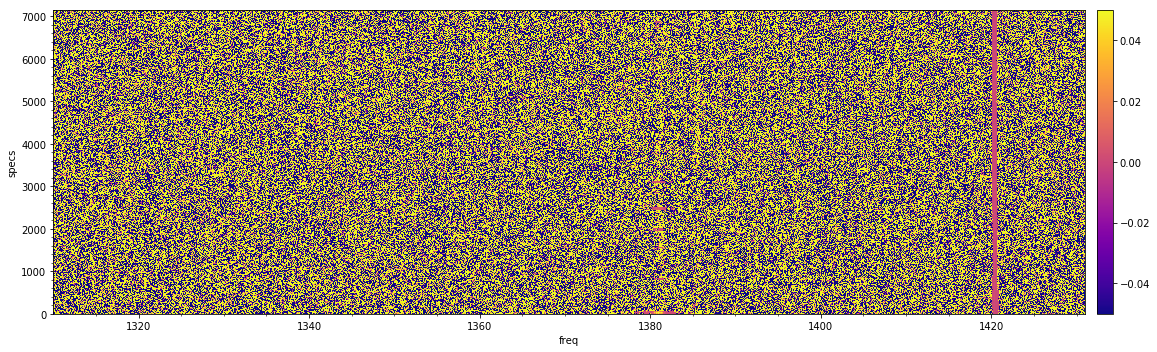

In [9]:
plot_waterfall(sub,data = data_xxs,vmin_max=[-.05,.05],cmap='plasma',figsize=(18,5))

三种方法对rfi的处理

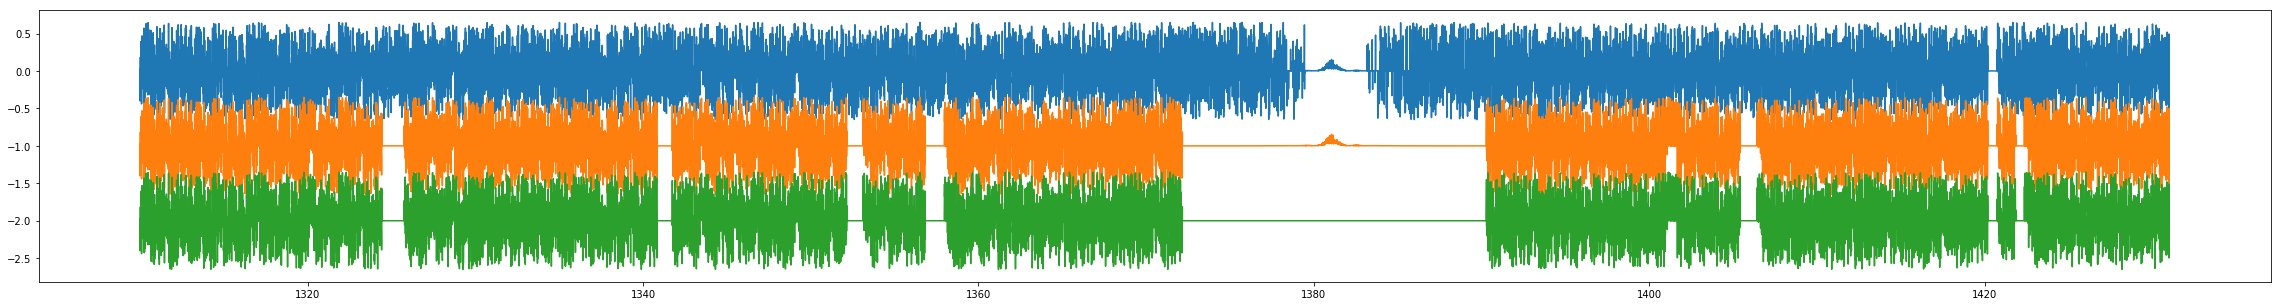

In [10]:
tn = 16
plt.figure(figsize=(40,5))
plt.plot(freq,data_xxs[tn])
plt.plot(freq,data_xxl[tn]-1)
plt.plot(freq,data_xxz[tn]-2)

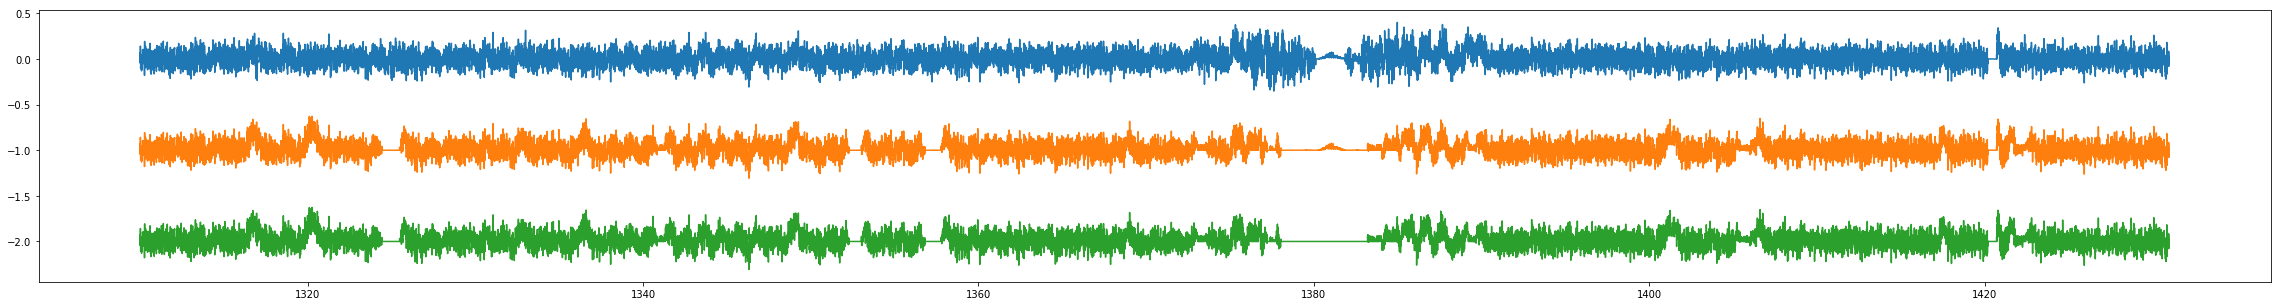

In [12]:
plt.figure(figsize=(40,5))
plt.plot(freq,np.mean(data_xxs[tn-5:tn+5,:],axis = 0))
plt.plot(freq,np.mean(data_xxl[tn-5:tn+5,:],axis = 0)-1)
plt.plot(freq,np.mean(data_xxz[tn-5:tn+5,:],axis = 0)-2)

(-2, 2)

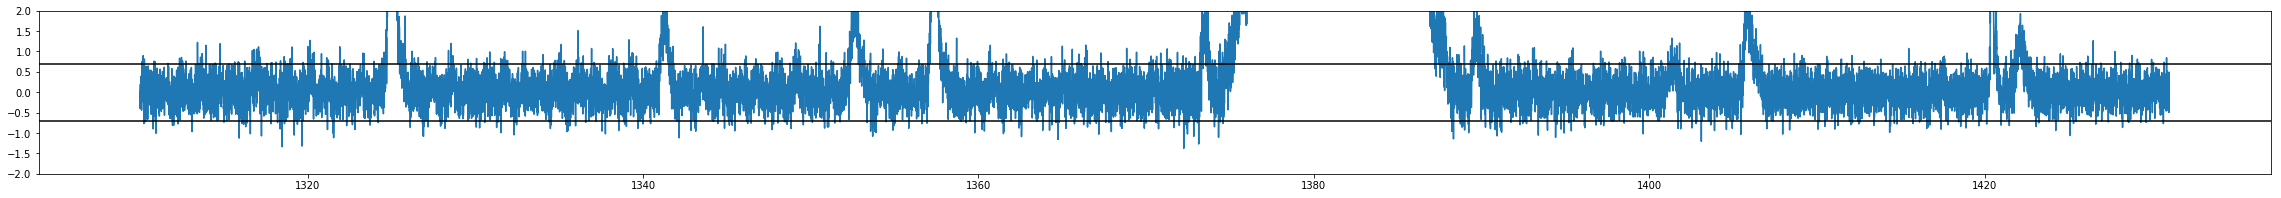

In [11]:
from markRFI import real_rms 
RMS = real_rms(data_x[tn,:],freq,sigma=6,rms_vrange=[freq[0],freq[0]+10])
thr = RMS*2 # times_lower_thr = 2
plt.figure(figsize=(40,3))
plt.plot(freq,data_x[tn])
plt.axhline(thr,c='k')
plt.axhline(-thr,c='k')
plt.ylim(-2,2)

# FFT remove 1MHz ripples

* --fft_method: 目前只提供rfft
* --sw_freq: 1mhz左右的驻波，在fourier空间为0.925$\mu$s左右
* --amp_thr: fourier空间的振幅大于阈值且处在1/16.2$\mu$s间隔RFI的模，被选中为驻波一部分
* --sw_n: 距离sw_freq中心左右各sw_n个通道数的模，作为0.925$\mu$s驻波的一部分被选中

* --rfi_8mhz: 是否fft去除8mhz rfi
* --rfi_freq_step: 残余的8.1MHzRFI，在fourier空间间隔为1/16.2$\mu$s左右

* -sep, --sep_fname: 只分离光谱温度定标的文件。无则自动到输入文件的上一级名为/sep/的文件夹里找含-tr的文件，找不到则在当前路径找。

In [13]:
sw_freq = 0.9254
rfi_freq_step = 1/16.2
amp_thr = 35
sw_n = 5
rfi_8mhz  = False
fit_args = {}
fit_args['sw_freq'] = sw_freq
fit_args['amp_thr'] = amp_thr
fit_args['sw_n'] = sw_n
fit_args['rfi_8mhz'] = rfi_8mhz 
fit_args['rfi_freq_step'] = rfi_freq_step

以subtract方法为例

(0, 2.5)

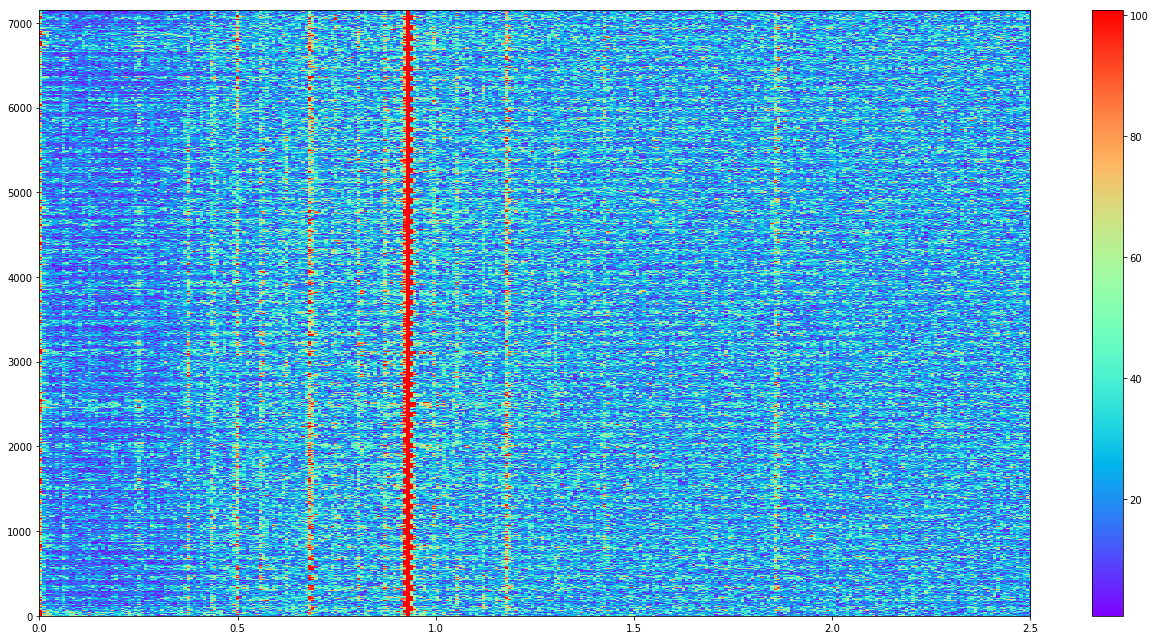

In [14]:
fftf = FFT(data_xxs, freq)
x = fftf.x
amp_data_x = fftf.amp
plt.figure(figsize=(18,9))
vmin,vmax = percent_vminmax(amp_data_x,percent = .999)
plt.imshow(amp_data_x,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data_x.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,2.5)

In [16]:
loc1 = np.argmin(np.abs((x - sw_freq)))
x_loc16 = np.arange(0,x[-1],rfi_freq_step)

N = freq.shape[0]
fdelta = freq[1]-freq[0]
fs = 1/fdelta
loc16 = np.around(x_loc16 / (fs/N)).astype('int')

loc16_ = np.hstack((loc16 - 1,loc16,loc16 + 1))
loc16_.sort()

(-0.1, 3)

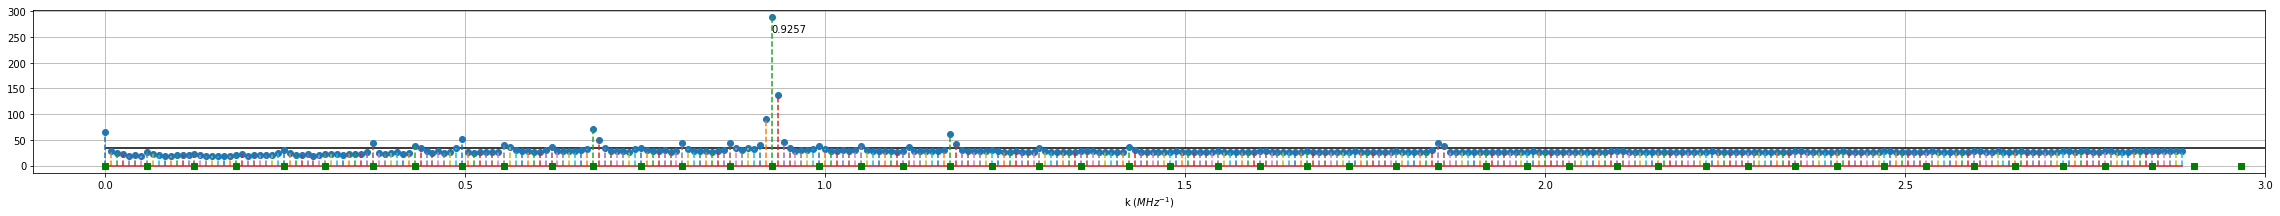

In [17]:
tn = 10
nplot0 = 0
nplot1 = 350
tspec = np.mean(amp_data_x,axis = 0)
fig,ax = plt.subplots(figsize=(40,3))
ax.stem(x[nplot0:nplot1],tspec[nplot0:nplot1],linefmt='--')
ax.text(x[loc1],tspec[loc1]*.9,f'{x[loc1]:.4f}')
ax.plot(x[loc16],np.zeros_like(loc16),'gs') # 有8MHz rfi成分
ax.hlines(amp_thr,0,3)
ax.grid()
ax.set_xlabel('k ($MHz^{-1}$)')
plt.xlim(-0.1,3)

(-0.1, 3)

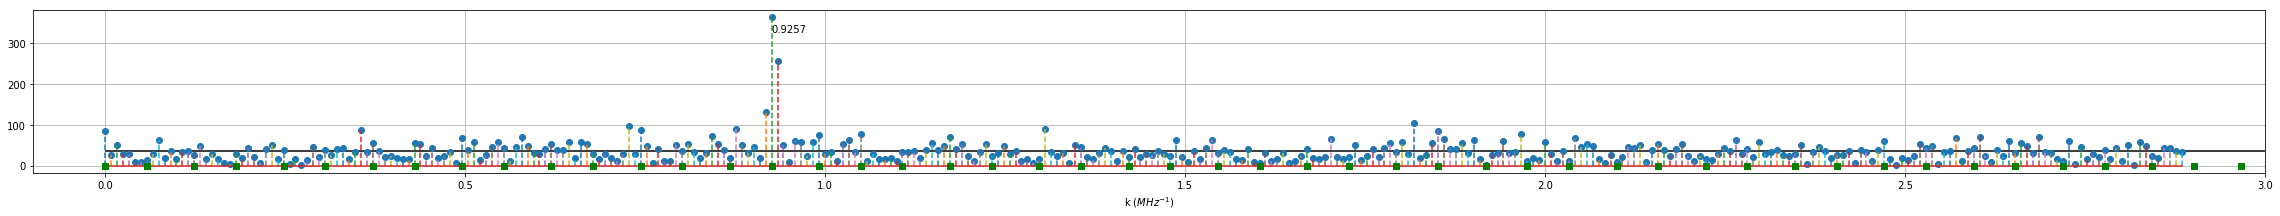

In [18]:
nplot0 = 0
nplot1 = 350
tn = 10
tspec = amp_data_x[tn,:]
fig,ax = plt.subplots(figsize=(40,3))
ax.stem(x[nplot0:nplot1],tspec[nplot0:nplot1],linefmt='--')
ax.text(x[loc1],tspec[loc1]*.9,f'{x[loc1]:.4f}')
ax.plot(x[loc16],np.zeros_like(loc16),'gs')
ax.hlines(amp_thr,0,3)
ax.grid()
ax.set_xlabel('k ($MHz^{-1}$)')
plt.xlim(-0.1,3)

In [19]:
whole_rfi = np.all(is_rfi,axis = 1)
not_rfi_num = np.arange(data_x.shape[0])[~whole_rfi]
is_rfi_num = np.arange(data_x.shape[0])[whole_rfi]
ori_shape = data_x.shape

对三种replace方法的都去驻波

In [20]:
# standing waves
sw_fit_xxs = fit_ripple(data_xxs,freq,'rfft', is_rfi_num,not_rfi_num,ori_shape,nspec = None,
               **fit_args)
sw_fit_xxl = fit_ripple(data_xxl,freq,'rfft', is_rfi_num,not_rfi_num,ori_shape,nspec = None,
               **fit_args)
sw_fit_xxz = fit_ripple(data_xxz,freq,'rfft', is_rfi_num,not_rfi_num,ori_shape,nspec = None,
               **fit_args)

INFO: Fit baseline ripple with rfft method ... [baseline_2]
INFO: Fit baseline ripple with rfft method ... [baseline_2]
INFO: Fit baseline ripple with rfft method ... [baseline_2]


In [21]:
# remove standing waves
rmsw_data_xxs = data_x - sw_fit_xxs
rmsw_data_xxl = data_x - sw_fit_xxl
rmsw_data_xxz = data_x - sw_fit_xxz

三种replace方法fft去驻波效果。平均10条谱线

(-1, 1)

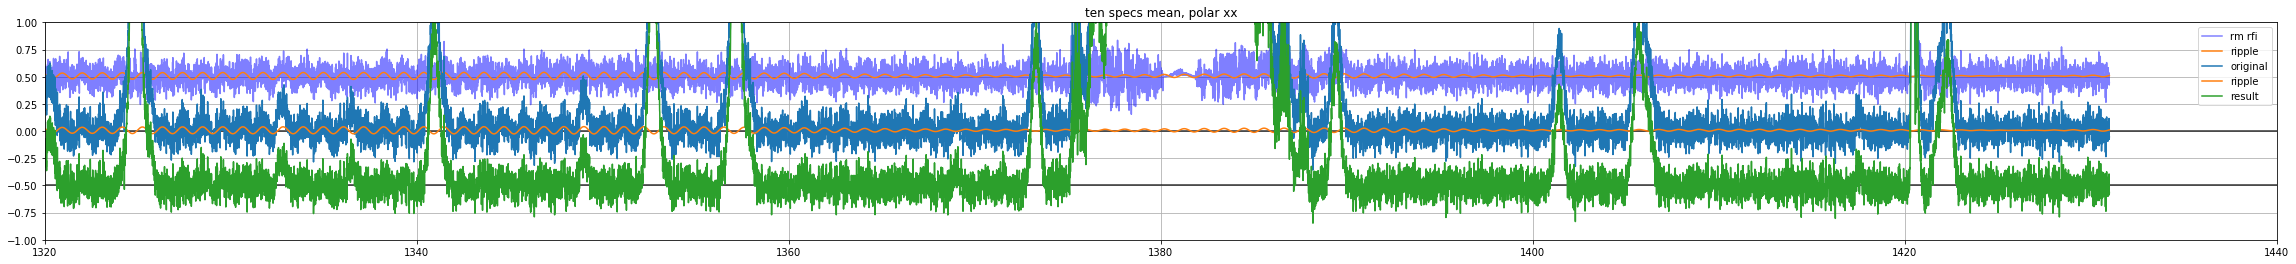

In [22]:
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.hlines([0,-.5],1320,1440,alpha = .8)
ax.plot(freq,np.mean(data_xxs[tn-5:tn+5,:],axis = 0)+.5,'b',label='rm rfi',alpha = .5)
ax.plot(freq,np.mean(sw_fit_xxs[tn-5:tn+5,:],axis = 0)+.5,c= 'C1',label='ripple')
ax.plot(freq,np.mean(data_x[tn-5:tn+5,:],axis = 0),label='original')
ax.plot(freq,np.mean(sw_fit_xxs[tn-5:tn+5,:],axis = 0),label='ripple')
ax.plot(freq,np.mean(rmsw_data_xxs[tn-5:tn+5,:],axis = 0) - .5,label='result')
ax.grid();ax.legend();ax.set_title(f'ten specs mean, polar xx')
ax.set_xlim(1320,1440)
ax.set_ylim(-1,1)

(-1, 1)

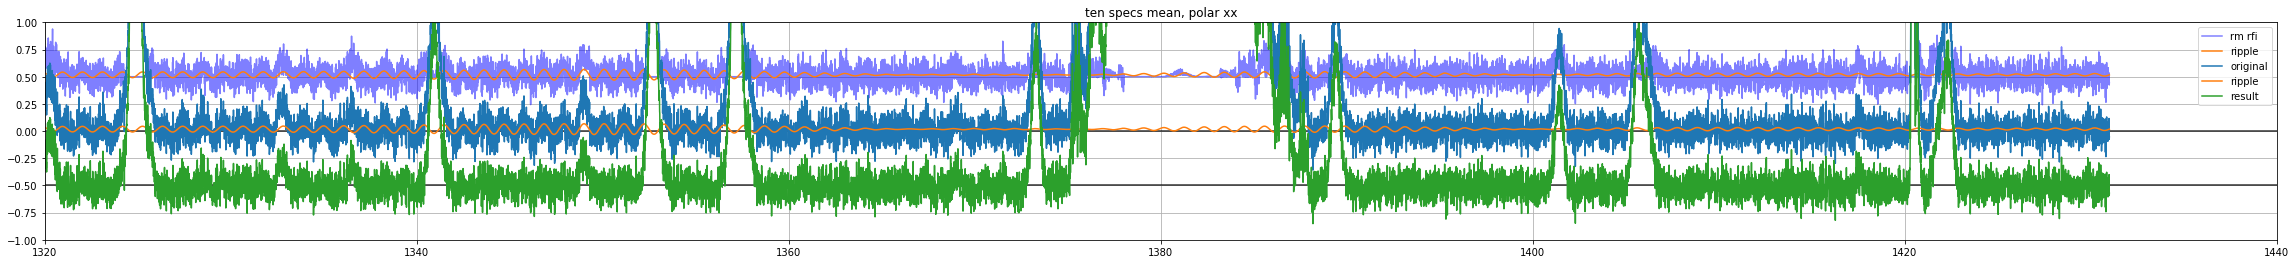

In [23]:
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.hlines([0,-.5],1320,1440,alpha = .8)
ax.plot(freq,np.mean(data_xxl[tn-5:tn+5,:],axis = 0)+.5,'b',label='rm rfi',alpha = .5)
ax.plot(freq,np.mean(sw_fit_xxl[tn-5:tn+5,:],axis = 0)+.5,c= 'C1',label='ripple')
ax.plot(freq,np.mean(data_x[tn-5:tn+5,:],axis = 0),label='original')
ax.plot(freq,np.mean(sw_fit_xxl[tn-5:tn+5,:],axis = 0),label='ripple')
ax.plot(freq,np.mean(rmsw_data_xxl[tn-5:tn+5,:],axis = 0) - .5,label='result')
ax.grid();ax.legend();ax.set_title(f'ten specs mean, polar xx')
ax.set_xlim(1320,1440)
ax.set_ylim(-1,1)

(-1, 1)

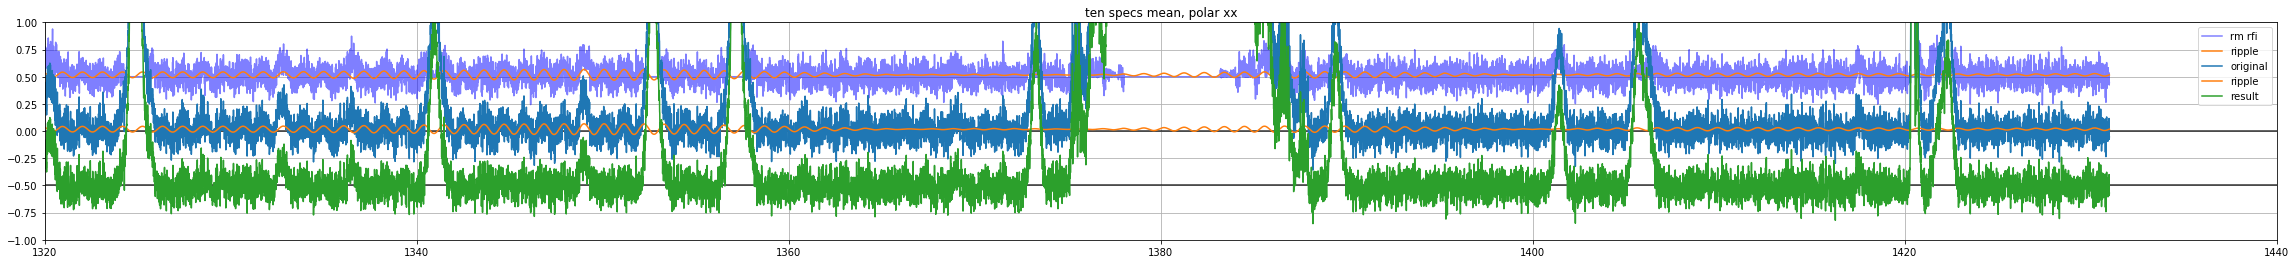

In [24]:
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.hlines([0,-.5],1320,1440,alpha = .8)
ax.plot(freq,np.mean(data_xxz[tn-5:tn+5,:],axis = 0)+.5,'b',label='rm rfi',alpha = .5)
ax.plot(freq,np.mean(sw_fit_xxz[tn-5:tn+5,:],axis = 0)+.5,c= 'C1',label='ripple')
ax.plot(freq,np.mean(data_x[tn-5:tn+5,:],axis = 0),label='original')
ax.plot(freq,np.mean(sw_fit_xxz[tn-5:tn+5,:],axis = 0),label='ripple')
ax.plot(freq,np.mean(rmsw_data_xxz[tn-5:tn+5,:],axis = 0) - .5,label='result')
ax.grid();ax.legend();ax.set_title(f'ten specs mean, polar xx')
ax.set_xlim(1320,1440)
ax.set_ylim(-1,1)

单独比较驻波

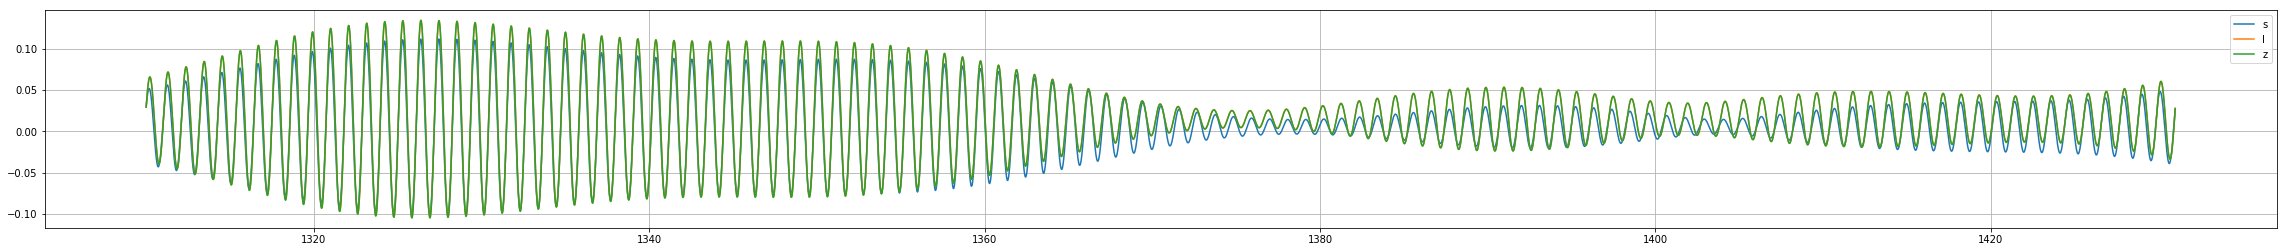

In [25]:
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.plot(freq,sw_fit_xxs[tn,:],label='s')
ax.plot(freq,sw_fit_xxl[tn,:],label='l')
ax.plot(freq,sw_fit_xxz[tn,:],label='z')
ax.grid();ax.legend();

# 平均谱线去基线(cli_baseline_mean)

In [26]:
sepname = '/data/inspur_disk04/FAST/liangtiantian/home/M31_v1/drift12/data/M31_Halo_Drift_12_arcdrift-M15_F-20200210-specs_T.hdf5'
sep = h5py.File(sepname,'r')
data_sep_x = get_data(sep,polar='xx')

## 平均10条

* --sub_method: mean，平均前后若干条谱线作为基线
* --nspec: 平均谱线条数，默认10条。过少容易损失信号，过多容易驻波变化了。

In [27]:
sw_mean_xx = fit_ripple(data_sep_x, method='mean',nspec=10)
rmsw_data_mean_xx = data_sep_x - sw_mean_xx

INFO: Fit baseline ripple with mean method ... [baseline_2]


100%|██████████| 7153/7153 [00:05<00:00, 1370.73it/s]


目前有周期RFI，所以效果不好。需要注意，由于不同谱线基线不同，还需要使用cli_baseline.py多项式去一次基线。